# Figure 6.4-4 &mdash; Pressure&ndash;enthalpy diagram for oxygen (Peng&ndash;Robinson EOS)

This notebook recreates **Figure 6.4-4** of Illustration 6.4-1, *Making of a
Thermodynamic Properties Chart*. It plots isotherms of oxygen in the
$P$&ndash;$\underline{H}$ plane from the Peng&ndash;Robinson equation of state,
together with the vapor&ndash;liquid two-phase region.

The enthalpy at each $(T, P)$ is the ideal-gas enthalpy plus the **enthalpy
departure** (SIS Eq. 6.4-29):

$$ \underline{H}(T,P) = \underline{H}^{\mathrm{IG}}(T)
   + \left[\underline{H}(T,P) - \underline{H}^{\mathrm{IG}}(T)\right] $$

with the reference state chosen (as in the book) to be the ideal gas at
$25\,^{\circ}$C and 1 bar, where $\underline{H} = 0$. Inside the two-phase region
an isotherm is horizontal (constant $T$ and $P$), running from the saturated
liquid to the saturated vapor; those tie lines and the envelope use the fugacity
condition of Chapter 7 (see Sec. 7.5).

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering
Thermodynamics*.

Eric Furst
July 2026

## Generalized Peng&ndash;Robinson equation of state

$$ P = \frac{RT}{\underline{V}-b} - \frac{a(T)}{\underline{V}(\underline{V}+b) + b(\underline{V}-b)} \tag{Eq. 6.4-2}$$

with $b = 0.07780\,RT_c/P_c$, $a(T) = 0.45724\,(R^2T_c^2/P_c)\,\alpha(T)$,
$\sqrt{\alpha} = 1 + \kappa(1-\sqrt{T/T_c})$, and
$\kappa = 0.37464 + 1.54226\,\omega - 0.26992\,\omega^2$ (Eqs. 6.7-1 to 6.7-4).
The molar volume follows from the cubic in $Z = P\underline{V}/RT$ (Eq. 6.4-4,
Table 6.4-3).

In [1]:
"""Generalized Peng-Robinson EOS for oxygen (SI units: K, Pa, m^3/mol)."""
import numpy as np
from scipy import constants
from numpy.polynomial import Polynomial

R = constants.R  # J/(mol K)

# Oxygen critical properties (SIS Table 6.6-1); omega = 0.021 gives kappa = 0.4069
Pc = 5.046e6   # Pa
Tc = 154.6     # K
omega = 0.021
kappa = 0.37464 + 1.54226 * omega - 0.26992 * omega**2


def calc_b(Pc, Tc):
    return 0.07780 * R * Tc / Pc


def calc_a(T, Pc, Tc, omega):
    sqrtalpha = 1 + kappa * (1 - np.sqrt(T / Tc))
    return 0.45724 * R**2 * Tc**2 / Pc * sqrtalpha**2


def calc_dadT(T, Pc, Tc, omega):
    """da/dT, needed for the enthalpy and entropy departures."""
    sqrtalpha = 1 + kappa * (1 - np.sqrt(T / Tc))
    return -0.45724 * R**2 * Tc**2 / Pc * kappa * sqrtalpha / np.sqrt(T * Tc)


def PR_pressure(V, T, Pc, Tc, omega):
    a, b = calc_a(T, Pc, Tc, omega), calc_b(Pc, Tc)
    return R * T / (V - b) - a / (V * (V + b) + b * (V - b))


def PR_roots_Z(P, T, Pc, Tc, omega):
    """Real compressibility roots (ascending) and the dimensionless A, B."""
    a, b = calc_a(T, Pc, Tc, omega), calc_b(Pc, Tc)
    A = a * P / R**2 / T**2
    B = b * P / R / T
    alpha = -1 + B
    beta = A - 3 * B**2 - 2 * B
    gamma = -A * B + B**2 + B**3
    roots = Polynomial([gamma, beta, alpha, 1]).roots()
    tol = 1e-6 * np.maximum(1.0, np.abs(roots.real))
    return np.sort(roots.real[np.abs(roots.imag) < tol]), A, B


def Z_phase(P, T, phase):
    Z, A, B = PR_roots_Z(P, T, Pc, Tc, omega)
    return (Z.max() if phase == "vapor" else Z.min()), A, B


print(f"oxygen: Tc = {Tc} K, Pc = {Pc/1e5:.2f} bar, kappa = {kappa:.4f}")


oxygen: Tc = 154.6 K, Pc = 50.46 bar, kappa = 0.4069


## Enthalpy: ideal-gas part + departure

The **enthalpy departure** for the Peng&ndash;Robinson equation of state is
(SIS Eq. 6.4-29)

$$ \underline{H} - \underline{H}^{\mathrm{IG}}
 = RT(Z-1) + \frac{T\,\dfrac{da}{dT} - a}{2\sqrt{2}\,b}\,
   \ln\!\left[\frac{Z+(1+\sqrt{2})B}{Z+(1-\sqrt{2})B}\right] $$

The ideal-gas enthalpy is the integral of the ideal-gas heat capacity from the
reference temperature,
$\underline{H}^{\mathrm{IG}}(T) = \int_{T_0}^{T} C_P^{\mathrm{IG}}\,dT$, with
$C_P^{\mathrm{IG}} = a_{C} + b_{C}T + c_{C}T^2 + d_{C}T^3$ (Appendix A.II form).
The reference state is the ideal gas at $T_0 = 25\,^{\circ}$C, 1 bar, with
$\underline{H} = 0$.

In [2]:
SQRT2 = np.sqrt(2.0)

# Ideal-gas heat-capacity coefficients for oxygen (Appendix A.II):
# Cp_IG = cA + cB*T + cC*T^2 + cD*T^3  [J/(mol K)]
cA, cB, cC, cD = 28.11, -3.68e-6, 1.746e-5, -1.065e-8

T_REF = 298.15   # 25 C
P_REF = 1e5      # 1 bar


def log_term(Z, B):
    return np.log((Z + (1 + SQRT2) * B) / (Z + (1 - SQRT2) * B))


def departure_H(P, T, phase):
    """H - H_ideal-gas at (T, P), J/mol (SIS Eq. 6.4-29)."""
    Z, A, B = Z_phase(P, T, phase)
    a, b = calc_a(T, Pc, Tc, omega), calc_b(Pc, Tc)
    dadT = calc_dadT(T, Pc, Tc, omega)
    return R * T * (Z - 1) + (T * dadT - a) / (2 * SQRT2 * b) * log_term(Z, B)


def H_ideal(T):
    """Ideal-gas enthalpy relative to T_REF, J/mol."""
    return (cA * (T - T_REF) + cB / 2 * (T**2 - T_REF**2)
            + cC / 3 * (T**3 - T_REF**3) + cD / 4 * (T**4 - T_REF**4))


def enthalpy(P, T, phase):
    """Molar enthalpy (J/mol) relative to the ideal gas at 25 C, 1 bar."""
    return H_ideal(T) + departure_H(P, T, phase)


# Reference check: at 25 C, 1 bar oxygen is very nearly (not quite) an ideal gas
print(f"H(25 C, 1 bar) = {enthalpy(P_REF, T_REF, 'vapor'):.2f} J/mol  (book: -9.44)")


H(25 C, 1 bar) = -9.45 J/mol  (book: -9.44)


## Saturation pressure and the two-phase envelope

For $T < T_c$ we find the saturation pressure by bracketing the equal-fugacity
condition between the isotherm's spinodal pressures (its loop maximum and
minimum) and solving with bisection &mdash; robust right up to the critical
point. The fugacity coefficient is

$$ \ln\frac{f}{P} = (Z-1) - \ln(Z-B) - \frac{A}{2\sqrt{2}\,B}\,
   \ln\!\left[\frac{Z+(1+\sqrt{2})B}{Z+(1-\sqrt{2})B}\right] $$

In [3]:
from scipy.optimize import brentq


def PR_lnphi(P, T, phase):
    Z, A, B = Z_phase(P, T, phase)
    return Z - 1 - np.log(Z - B) - A / (2 * SQRT2 * B) * log_term(Z, B)


def loop_pressure_bounds(T, n=4000):
    """Spinodal pressures (loop max, loop min); None once the loop vanishes."""
    b = calc_b(Pc, Tc)
    V = np.logspace(np.log10(1.001 * b), np.log10(0.02), n)
    P = PR_pressure(V, T, Pc, Tc, omega)
    turns = np.where(np.diff(np.sign(np.diff(P))) != 0)[0]
    if len(turns) < 2:
        return None
    return P[turns].min(), P[turns].max()


def Psat(T):
    """Saturation pressure (Pa) at T (K), or None at/above the critical point."""
    bounds = loop_pressure_bounds(T)
    if bounds is None:
        return None
    P_lo, P_hi = max(1.0, bounds[0]) * 1.0001, bounds[1] * 0.9999
    resid = lambda P: PR_lnphi(P, T, "liquid") - PR_lnphi(P, T, "vapor")
    if resid(P_lo) * resid(P_hi) > 0:
        return None
    return brentq(resid, P_lo, P_hi, xtol=1.0, rtol=1e-12, maxiter=200)


print(f"P_sat(-183 C) = {Psat(-183 + 273.15)/1e5:.3f} bar  (O2 normal boiling point)")


P_sat(-183 C) = 1.027 bar  (O2 normal boiling point)


### Build the saturation envelope

The envelope records the saturated-liquid and saturated-vapor **enthalpies** at
each saturation pressure. The temperature grid is clustered toward $T_c$, and the
curve is closed with the exact critical point.

In [4]:
import pandas as pd

TO_KELVIN = 273.15
BAR = 1e5

frac = np.geomspace(2e-3, 1.0, 500)
T_list = np.sort(Tc - (Tc - 63.0) * frac)   # 63 K (~ -210 C) up toward Tc

rows = []
for T in T_list:
    ps = Psat(T)
    if ps is None:
        continue
    Z, A, B = PR_roots_Z(ps, T, Pc, Tc, omega)
    if len(Z) < 2 or (Z.max() - Z.min()) < 1e-7:
        continue
    rows.append({"T": T, "P": ps,
                 "HL": enthalpy(ps, T, "liquid"),
                 "HV": enthalpy(ps, T, "vapor")})

Hc = enthalpy(Pc, Tc, "vapor")   # critical enthalpy
rows.append({"T": Tc, "P": Pc, "HL": Hc, "HV": Hc})

envelope = pd.DataFrame(rows).sort_values("T").reset_index(drop=True)
print(f"{len(envelope)} envelope points; critical H = {Hc/1000:.2f} kJ/mol")
envelope.tail()


501 envelope points; critical H = -7.15 kJ/mol


,T,P,HL,HV
496,154.409826,5.011014e+06,-7484.781151,-7019.370546
497,154.412180,5.011451e+06,-7483.235929,-7020.780015
498,154.414504,5.011883e+06,-7481.700512,-7022.181485
499,154.416800,5.012309e+06,-7480.174686,-7023.574821
500,154.600000,5.046000e+06,-7147.101243,-7147.101243


## Figure 6.4-4

Supercritical isotherms are single curves; sub-critical isotherms drop from the
vapor region (low $P$, high $\underline{H}$) to the saturation pressure, run
horizontally across the two-phase region to the saturated liquid, and rise
steeply through the compressed liquid. Enthalpy is plotted in kJ/mol.

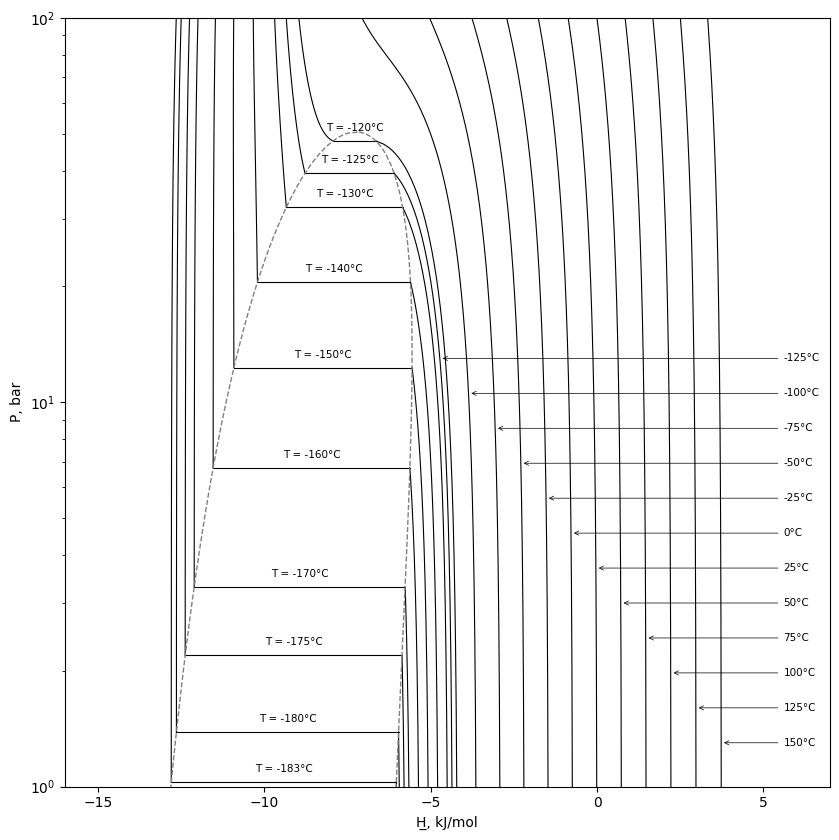

In [9]:
import os
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.5, 8.5))
BLACK = "black"
KJ = 1e3   # J per kJ

supercrit = [-100, -75, -50, -25, 0, 25, 50, 75, 100, 125, 150]  # single curves
subcrit = [-120, -125, -130, -140, -150, -160, -170, -175, -180, -183]


def H_kJ(P, T, phase):
    return enthalpy(P, T, phase) / KJ


# --- supercritical isotherms ---
for TC in supercrit:
    T = TC + TO_KELVIN
    P = np.logspace(0, 2, 400) * BAR   # 1 .. 100 bar
    ax.plot([H_kJ(p, T, "vapor") for p in P], P / BAR, "-", color=BLACK, lw=0.8)

# --- sub-critical isotherms: vapor branch + tie line + liquid branch ---
for TC in subcrit:
    T = TC + TO_KELVIN
    ps = Psat(T)
    if ps is None:
        continue
    Pv = np.logspace(0, np.log10(ps / BAR), 200) * BAR
    ax.plot([H_kJ(p, T, "vapor") for p in Pv], Pv / BAR, "-", color=BLACK, lw=0.8)
    Pl = np.logspace(np.log10(ps / BAR), 2, 120) * BAR
    ax.plot([H_kJ(p, T, "liquid") for p in Pl], Pl / BAR, "-", color=BLACK, lw=0.8)
    ax.plot([H_kJ(ps, T, "vapor"), H_kJ(ps, T, "liquid")], [ps / BAR, ps / BAR],
            "-", color=BLACK, lw=0.8)
    # tie-line temperature label, centred on the line
    Hmid = 0.5 * (H_kJ(ps, T, "vapor") + H_kJ(ps, T, "liquid"))
    ax.text(Hmid, ps / BAR * 1.05, f"T = {TC}°C", fontsize=7.5,
            ha="center", va="bottom")

# --- two-phase envelope + critical point ---
ax.plot(envelope.HL / KJ, envelope.P / BAR, "--", color="gray", lw=1)
ax.plot(envelope.HV / KJ, envelope.P / BAR, "--", color="gray", lw=1)

# --- temperature key on the right, arrows to the vapor isotherms ---
key_T = [-125, -100, -75, -50, -25, 0, 25, 50, 75, 100, 125, 150]
P_key = np.logspace(np.log10(13), np.log10(1.3), len(key_T))   # bar
for TC, P_lab in zip(key_T, P_key):
    T = TC + TO_KELVIN
    H_head = H_kJ(P_lab * BAR, T, "vapor")
    ax.annotate(f"{TC}°C",
                xy=(H_head, P_lab), xycoords="data",
                xytext=(5.6, P_lab), textcoords="data",
                fontsize=7.5, va="center", ha="left",
                arrowprops=dict(arrowstyle="->", lw=0.5, color=BLACK))

ax.set_yscale("log")
ax.set_xlim(-16, 7)
ax.set_ylim(1, 100)
ax.set_xlabel("H̲, kJ/mol")   # underbar H = molar enthalpy (book notation)
ax.set_ylabel("P, bar")

os.makedirs("pdf", exist_ok=True)
plt.tight_layout()
plt.savefig("pdf/Fig_6.4-4.pdf", dpi=300, bbox_inches="tight")
plt.show()
